['MONTH', 'WEEK_NUM']


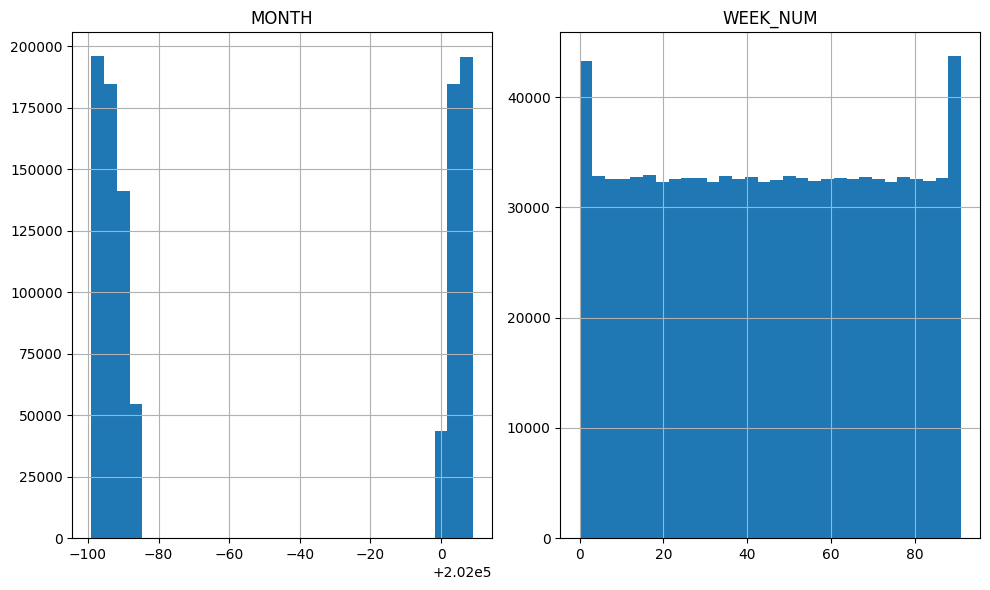

In [7]:
from pathlib import Path

# Dataset lives in the repo's data/raw folder (git-ignored; see README).
# Notebooks run from notebooks/, so the repo root is one level up.
DATA_DIR = Path.cwd().parent / "data" / "raw" / "csv_files"

# Base Table EDA Then Check for Missing Values or Outliers.

# Goal: Fully Understand `train_base.csv` before joining other tables. After That, then check for missing values and outliers.
# Documented Results And Findings

# - Dataset size: 1,000,000 rows
# -`case_id` is unique to include one row per loan application
# - No missing values in the base table
# - Date range: 2019-01-01 to 2020-09-29
# - Target rate declines over time
# - No Missing values or Outliers in the base table


import pandas as pd
import matplotlib.pyplot as plt



# Load the Base training table

train = pd.read_csv(DATA_DIR / "train" / "train_base.csv", low_memory=False)

# Removes and elminates the ID and prediction target from feature histograms

# Finds all of the numeric columns in the dataset
numeric_cols = train.select_dtypes(include="number").columns.tolist()

# Remove the ID and target columns
numeric_cols = [
    c for c in numeric_cols
    if c not in ["case_id", "target"]
]


# Chosed up to the first four numeric feature columns available
cols = numeric_cols[:4]

# Confirmed which columns will be plotted
print(cols)

# Plotted a histogram for each selected numeric column
train[cols].hist(bins=30, figsize=(10, 6))

# Prevent the titles and axes from overlapping
plt.tight_layout()
plt.show()

# Week_Num looks evenly distributed. 
# However the Month feature is not and is heavily skewed to -100 and 0 on the x-axis and alomost at 200,000.
# Week_Num does not show much outliers, however Month might show some pontential outliers.


In [ ]:
## Count applications by decision month

#This counts the number of applications in each `MONTH` value and sorts the results chronologically or in order. 
# `MONTH` uses the YYYYMM format; for example, `201901` represents January 2019.


print(train["MONTH"].value_counts().sort_index())

 

MONTH
201901    54324
201902    43464
201903    43437
201904    54611
201905    43395
201906    43534
201907    54386
201908    43251
201909    43532
201910    54336
201911    43369
201912    54614
202001    43373
202002    43322
202003    54525
202004    43460
202005    43364
202006    54320
202007    43522
202008    43187
202009    54674
Name: count, dtype: int64


In [35]:
# Extract the month number: 201901 -> 1
train["MONTH_NUM"] = train["MONTH"] % 100

print(train["MONTH_NUM"].value_counts().sort_index())


MONTH_NUM
1     97697
2     86786
3     97962
4     98071
5     86759
6     97854
7     97908
8     86438
9     98206
10    54336
11    43369
12    54614
Name: count, dtype: int64


In [ ]:
# Extract the year: 201901 -> 2019
train["YEAR"] = train["MONTH"] // 100
#This counts the number of applications in each `YEAR` value and sorts the results chronologically or in order. 
print(train["YEAR"].value_counts().sort_index()) 





YEAR
2019    576253
2020    423747
Name: count, dtype: int64


In [ ]:
# View dataset dimensions with rows and columns and sample records
print(train.shape)
#Viewing DataFrame information and summary statistics can help identify potential issues with the data, such as missing values, incorrect data types, or unexpected distributions. It also provides a quick overview of the dataset's structure and content.
print(train.head()) 


(1000000, 7)
   case_id date_decision   MONTH  WEEK_NUM  target  MONTH_NUM  YEAR
0        1    2020-04-28  202004        69       0          4  2020
1        2    2019-08-13  201908        32       0          8  2019
2        3    2019-01-01  201901         0       1          1  2019
3        4    2019-08-27  201908        34       1          8  2019
4        5    2019-03-26  201903        12       0          3  2019


In [ ]:
# Notes: The target rate is decreasing such as 2019: 20.12% and 2020: 17.89%
# So the target is less common and frequent in 2020 than in 2019 so about a 2.24 percentage-point decrease. This means time could pontentially matter in the model, so keeping YEAR, MONTH_NUM, or properly parsed date_decision could be benefital useful.

train.groupby("YEAR")["target"].mean() 

# Notes: Good Result and Finding: The target rate gradually decreases over time.
# January 2019: 21.27% -> December 2019: 18.82% -> September 2020: 17.16%
train.groupby("MONTH")["target"].mean() 



MONTH
201901    0.212650
201902    0.211623
201903    0.208877
201904    0.206167
201905    0.203894
201906    0.201773
201907    0.200934
201908    0.199071
201909    0.198383
201910    0.193150
201911    0.191381
201912    0.188248
202001    0.183040
202002    0.183071
202003    0.183457
202004    0.181822
202005    0.178604
202006    0.177080
202007    0.179013
202008    0.173084
202009    0.171617
Name: target, dtype: float64

In [ ]:
#date_decision and MONTH match correctly. For example: 2020-04-28 -> 202004, 2019-08-13 ->201908
#2019-01-01 ->201901
# So MONTH, MONTH_NUM, and YEAR  origniate from date_decision. Meaning all four as model features are not needed because they repeat the same information.

train[["date_decision", "MONTH"]].head(10)



,date_decision,MONTH
0,2020-04-28,202004
1,2019-08-13,201908
2,2019-01-01,201901
3,2019-08-27,201908
4,2019-03-26,201903
5,2019-12-31,201912
6,2019-10-22,201910
7,2020-04-21,202004
8,2019-11-19,201911
9,2019-04-23,201904


In [ ]:
print(train["date_decision"].isna().sum()) # No missing values
print(train["date_decision"].min()) # Minimum date
print(train["date_decision"].max()) # Maximum date


# Count duplicate application IDs
print(train["case_id"].duplicated().sum())
# Notes: case_id has 0 duplicates, so train_base.csv is one row per case.
# That means case_id ia the main base table. Any other table with repeated case_id values should be summarized to one row per case_id before it is merged or combined into the train.

# Count missing values per column
print(train.isna().sum())


train.head(1000000)

0
2019-01-01
2020-09-29
0
case_id          0
date_decision    0
MONTH            0
WEEK_NUM         0
target           0
MONTH_NUM        0
YEAR             0
dtype: int64


,case_id,date_decision,MONTH,WEEK_NUM,target,MONTH_NUM,YEAR
0,1,2020-04-28,202004,69,0,4,2020
1,2,2019-08-13,201908,32,0,8,2019
2,3,2019-01-01,201901,0,1,1,2019
3,4,2019-08-27,201908,34,1,8,2019
4,5,2019-03-26,201903,12,0,3,2019
...,...,...,...,...,...,...,...
999995,999996,2019-06-04,201906,22,0,6,2019
999996,999997,2020-06-30,202006,78,1,6,2020
999997,999998,2019-07-02,201907,26,1,7,2019
999998,999999,2020-07-28,202007,82,0,7,2020
